C:\Users\eucli\AppData\Local\Temp\ipykernel_12252\907846352.py:22: UserWarning: The filter's denominator is extremely small at frequencies [3.109, 3.110, 3.112, 3.113, 3.115, 3.116, 3.118, 3.120, 3.121, 3.123, 3.124, 3.126, 3.127, 3.129, 3.131, 3.132, 3.134, 3.135, 3.137, 3.138, 3.140], around which a singularity may be present
  w, gd_iir8 = signal.group_delay((b_iir_ordem8, a_iir_ordem8), w=2000, fs=fs)


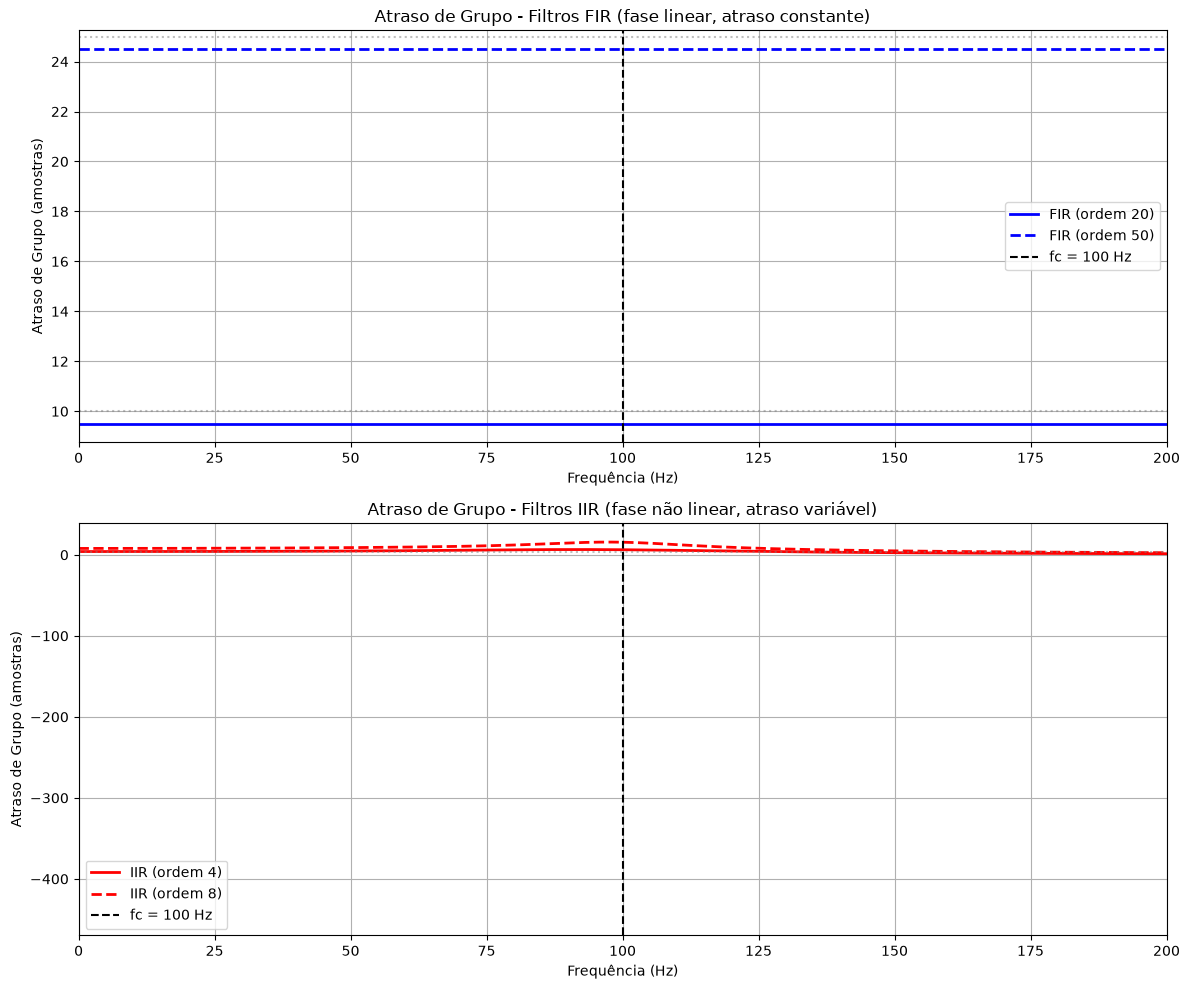

Atraso de Grupo na Banda de Passagem:
FIR ordem 20: 9.50 ± 0.00 amostras
FIR ordem 50: 24.50 ± 0.00 amostras
IIR ordem 4: 5.00 ± 0.91 amostras
IIR ordem 8: 9.99 ± 2.44 amostras

Importância do Atraso de Grupo em Sistemas de Comunicação:
• Atraso de grupo constante = preservação da forma do sinal
• Atraso de grupo variável = distorção de fase
• Em modulação digital, variação de atraso causa ISI
• Em áudio, variação de atraso afeta a percepção de som


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parâmetros
fs = 1000
fc = 100  # Hz
freq_test = 80  # Frequência de teste

# Filtros
b_fir_ordem20 = signal.firwin(20, fc, fs=fs, window='hamming')
b_fir_ordem50 = signal.firwin(50, fc, fs=fs, window='hamming')
b_iir_ordem4 = signal.butter(4, fc, fs=fs, btype='low')[0]
a_iir_ordem4 = signal.butter(4, fc, fs=fs, btype='low')[1]
b_iir_ordem8 = signal.butter(8, fc, fs=fs, btype='low')[0]
a_iir_ordem8 = signal.butter(8, fc, fs=fs, btype='low')[1]

# Atraso de grupo
w, gd_fir20 = signal.group_delay((b_fir_ordem20, [1.0]), w=2000, fs=fs)
w, gd_fir50 = signal.group_delay((b_fir_ordem50, [1.0]), w=2000, fs=fs)
w, gd_iir4 = signal.group_delay((b_iir_ordem4, a_iir_ordem4), w=2000, fs=fs)
w, gd_iir8 = signal.group_delay((b_iir_ordem8, a_iir_ordem8), w=2000, fs=fs)

# Gráficos
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Comparação FIR
axes[0].plot(w, gd_fir20, 'b-', label='FIR (ordem 20)', linewidth=2)
axes[0].plot(w, gd_fir50, 'b--', label='FIR (ordem 50)', linewidth=2)
axes[0].axvline(fc, color='k', linestyle='--', label=f'fc = {fc} Hz')
axes[0].axhline(10, color='gray', linestyle=':', alpha=0.5)
axes[0].axhline(25, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Frequência (Hz)')
axes[0].set_ylabel('Atraso de Grupo (amostras)')
axes[0].set_title('Atraso de Grupo - Filtros FIR (fase linear, atraso constante)')
axes[0].set_xlim(0, 200)
axes[0].legend()
axes[0].grid()

# Comparação IIR
axes[1].plot(w, gd_iir4, 'r-', label='IIR (ordem 4)', linewidth=2)
axes[1].plot(w, gd_iir8, 'r--', label='IIR (ordem 8)', linewidth=2)
axes[1].axvline(fc, color='k', linestyle='--', label=f'fc = {fc} Hz')
axes[1].axhline(3, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Frequência (Hz)')
axes[1].set_ylabel('Atraso de Grupo (amostras)')
axes[1].set_title('Atraso de Grupo - Filtros IIR (fase não linear, atraso variável)')
axes[1].set_xlim(0, 200)
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# Valores na banda de passagem
idx = w < fc
print("Atraso de Grupo na Banda de Passagem:")
print(f"FIR ordem 20: {np.mean(gd_fir20[idx]):.2f} ± {np.std(gd_fir20[idx]):.2f} amostras")
print(f"FIR ordem 50: {np.mean(gd_fir50[idx]):.2f} ± {np.std(gd_fir50[idx]):.2f} amostras")
print(f"IIR ordem 4: {np.mean(gd_iir4[idx]):.2f} ± {np.std(gd_iir4[idx]):.2f} amostras")
print(f"IIR ordem 8: {np.mean(gd_iir8[idx]):.2f} ± {np.std(gd_iir8[idx]):.2f} amostras")

print("\nImportância do Atraso de Grupo em Sistemas de Comunicação:")
print("• Atraso de grupo constante = preservação da forma do sinal")
print("• Atraso de grupo variável = distorção de fase")
print("• Em modulação digital, variação de atraso causa ISI")
print("• Em áudio, variação de atraso afeta a percepção de som")

# Discussão dos Resultados
O atraso de grupo é constante para filtros FIR com fase linear, sendo proporcional à ordem do filtro. Aumentar a ordem do FIR aumenta o atraso, mas mantém sua constância. Para filtros IIR, o atraso de grupo varia com a frequência, sendo maior próximo à frequência de corte. Em sistemas de comunicação, atraso de grupo variável pode causar distorção de fase e interferência entre símbolos (ISI), degradando a qualidade da transmissão.